In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
ROOT_PATH = "/content/drive/MyDrive/chiliSummerProject/src"
print(os.listdir(ROOT_PATH))
sys.path.append(ROOT_PATH)

['helper.py', 'data_exploration.ipynb', 'skel_cap_ipmg_map_logic.ipynb', 'model_exploration.ipynb', 'evaluation.ipynb', 'model_eval.ipynb', '__pycache__', 'logs', 'generate_data.ipynb', 'my_helpers.py', 'define_model.py', 'model_scratch.ipynb']


In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import numpy as np
import pandas as pd
import glob
from helper import *
from define_model import *
from my_helpers import *
import pprint as p
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau
from sklearn.utils import shuffle
from sklearn.metrics import f1_score
import seaborn as sns



In [21]:
p.pprint(tf.test.is_built_with_cuda())
print('*'*50)
p.pprint(tf.config.list_physical_devices('GPU'))
print('*'*50)
p.pprint(tf.test.gpu_device_name())

True
**************************************************
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
**************************************************
'/device:GPU:0'


2023-08-21 15:41:51.780263: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-21 15:41:51.780587: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-21 15:41:51.780796: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-21 15:41:51.781048: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-21 15:41:51.781272: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from S

In [22]:
drive = 0 # 1 if on google drive, 0 if not
data_dir = "/content/drive/MyDrive/chiliSummerProject/data/" if drive else "../data/"
model_path = "/content/drive/MyDrive/chiliSummerProject/models/" if drive else "../models/"
chili_models = model_path + "chili_models/"
identifier_eth = "TouchPose_crossGestures"
data_path_eth = data_dir + "eth_data/"
data_path_chili= data_dir + "processed/native_mapped/"
#set random seeds
np.random.seed(42)
tf.random.set_seed(42)

In [23]:
files = glob.glob(data_path_chili+'*.pkl')
files.remove(data_path_chili+'day3003.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x.astype(np.float32))
max_skel = np.max(chili_data['skeleton'].apply(lambda x : np.max(x)))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
#chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x/max_skel)
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
print(chili_data.Timestamp.is_unique)
#chili_data.set_index('Timestamp', inplace=True)
#hili_data.sort_index(inplace=True)
print(len(chili_data))
chili_data.head()

True
38426


,Timestamp,skeleton,ScanSizeX,ScanSizeY,trial,gesture,subject,day,cap_img
0,1.679995e+12,"[[-236.0, 306.0, 164.0], [-234.0, 288.0, 137.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,1.679995e+12,"[[-236.0, 307.0, 164.0], [-234.0, 288.0, 137.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,1.679995e+12,"[[-236.0, 307.0, 163.0], [-234.0, 288.0, 137.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,1.679995e+12,"[[-235.0, 307.0, 163.0], [-234.0, 287.0, 136.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,1.679995e+12,"[[-235.0, 306.0, 162.0], [-234.0, 286.0, 136.0...",72,41,1,DQ,1,2803,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


# Cross validation gesture model

In [24]:
def max_end_point_error(y_true,y_pred) :
    distances = tf.sqrt(tf.reduce_sum(tf.square(y_true - y_pred), axis=0))
    print(distances.shape)
    max_index = tf.math.top_k(distances,k=5)
    return max_index

for g in chili_data.gesture.unique() :
    model = load_model(chili_models+'/crossGesture/crossmulti_beta0.2_'+str(g)+'.h5',compile=False)
    print('test set on '+g)
    test = shuffle(chili_data[chili_data.gesture==g].copy(),random_state=42)
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)
    y_out_gesture, y_out_skeleton = model.predict(X_test, batch_size=32)
    skeleton_error = np.mean(abs(y_test_skeleton - y_out_skeleton))
    auc = auc_pck(y_test_skeleton,y_out_skeleton).numpy()
    epe = end_point_error(y_test_skeleton,y_out_skeleton).numpy()
    epe_max = max_end_point_error(y_test_skeleton,y_out_skeleton)
    y_out_gesture_labels = np.argmax(y_out_gesture, axis=1)
    y_test_gesture_labels = np.argmax(y_test_gesture, axis=1)
    gesture_accuracy = np.mean(y_out_gesture_labels == y_test_gesture_labels)
    gesture_f1_score = f1_score(y_test_gesture_labels, y_out_gesture_labels, average='weighted')
    print("Gesture Accuracy: ", gesture_accuracy)
    print("Gesture F1 Score: ", gesture_f1_score)
    print("Mean Error: ",skeleton_error)
    print("AucPCK : ", auc)
    print("End point error ", epe)
    print("Top 5 joint index with largest epe : ", epe_max.values.numpy(),epe_max.indices.numpy())
    print('*'*50)

test set on DQ
(63,)
Gesture Accuracy:  0.0
Gesture F1 Score:  0.0
Mean Error:  20.716606
AucPCK :  [0.         0.         0.42465952 1.1129009  2.1379411  3.7194319
 5.549861  ]
End point error  211.0519
Top 5 joint index with largest epe :  [4949.1646 4905.027  4890.004  4784.2534 4649.4062] [57 60 45 48 33]
**************************************************
test set on DT
(63,)
Gesture Accuracy:  0.0
Gesture F1 Score:  0.0
Mean Error:  27.927483
AucPCK :  [0.02525571 0.07576714 0.25255716 0.63139284 1.1617628  1.7489582
 2.6265943 ]
End point error  276.88855
Top 5 joint index with largest epe :  [9796.304 9729.292 9526.473 9449.101 9417.083] [36 48 45 33 60]
**************************************************
test set on LQ
(63,)
Gesture Accuracy:  0.3259031514219831
Gesture F1 Score:  0.4915942028985507
Mean Error:  22.71376
AucPCK :  [0.         0.         0.03843198 0.24980783 0.99923134 2.7286704
 5.3036127 ]
End point error  231.08371
Top 5 joint index with largest epe :  [5313

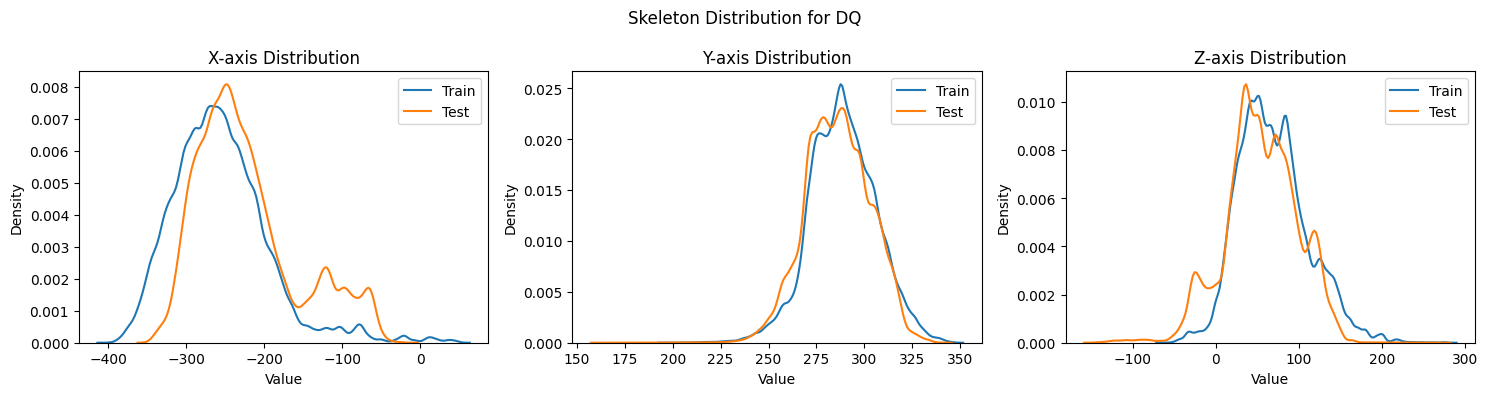

Percentage of zeroes in capactive train data for DQ:  98.66928359206686
Percentage of zeroes in capacitive test data for DQ:  98.11524837682116


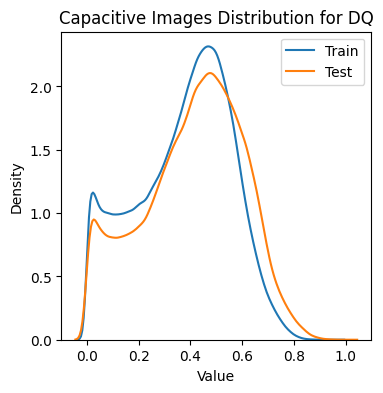

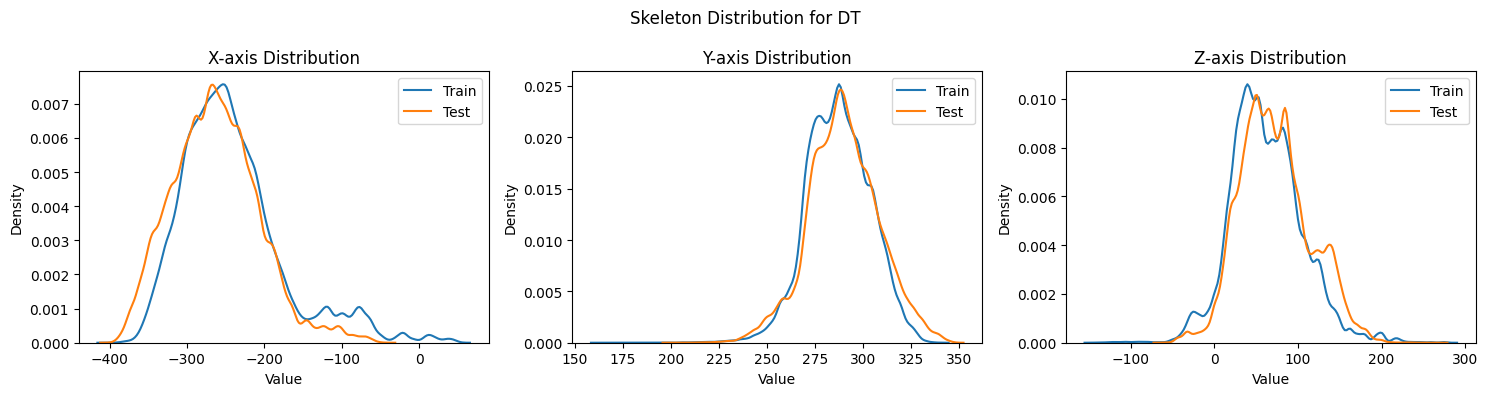

Percentage of zeroes in capactive train data for DT:  98.58153992598895
Percentage of zeroes in capacitive test data for DT:  98.55553485134548


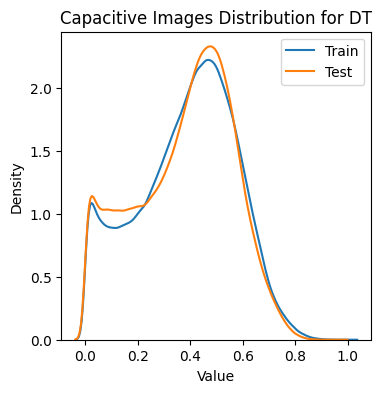

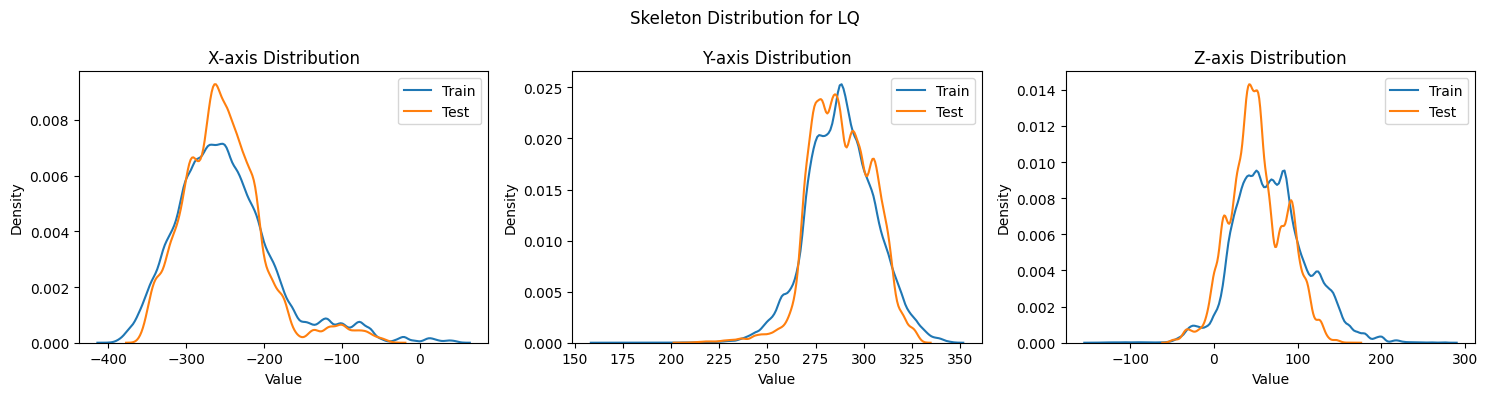

Percentage of zeroes in capactive train data for LQ:  98.50554612568581
Percentage of zeroes in capacitive test data for LQ:  98.98753486477986


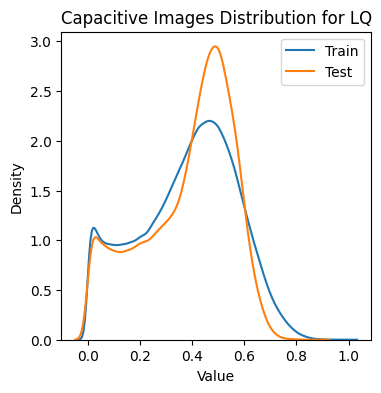

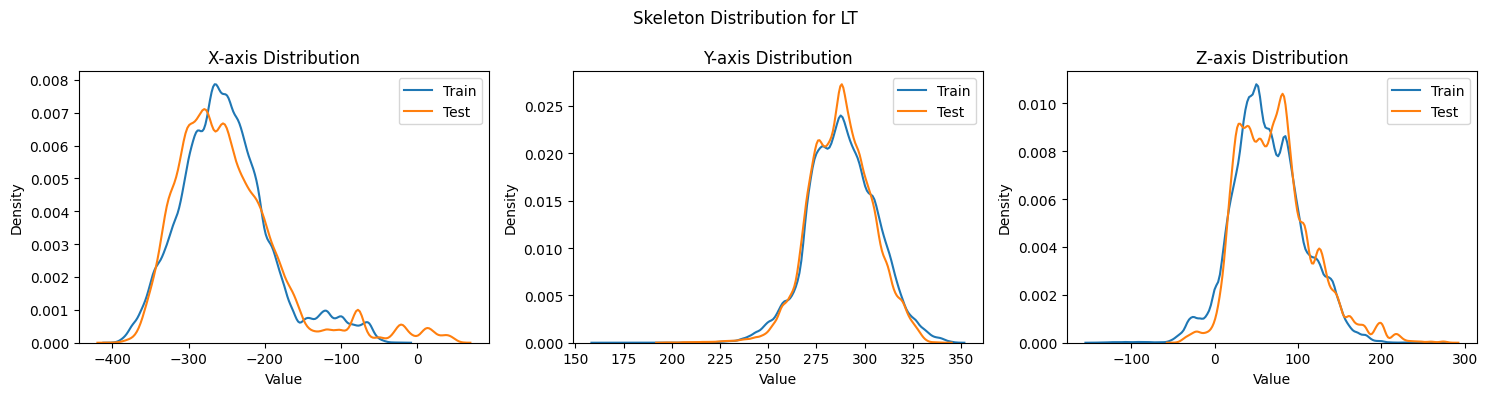

Percentage of zeroes in capactive train data for LT:  98.52831701687187
Percentage of zeroes in capacitive test data for LT:  98.68305648949432


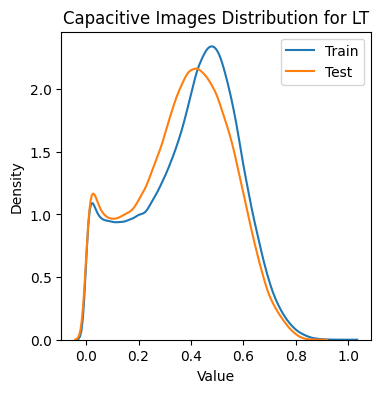

In [7]:
for g in chili_data.gesture.unique() :
    train = shuffle(chili_data[chili_data.gesture!=g].copy(),random_state=42)
    test = shuffle(chili_data[chili_data.gesture==g].copy(),random_state=42)
    train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

    #skeleton distributions
    y_train_skel = y_train_skeleton.reshape(-1,21,3)
    y_test_skel = y_test_skeleton.reshape(-1,21,3)
    x_train,y_train,z_train = y_train_skel[:,:,0], y_train_skel[:,:,1], y_train_skel[:,:,2]
    x_test,y_test,z_test = y_test_skel[:,:,0], y_test_skel[:,:,1], y_test_skel[:,:,2]  
    plt.figure(figsize=(15, 4))
    train_axes = [x_train,y_train,z_train]
    test_axes = [x_test,y_test,z_test]
    axes = ['X','Y','Z']
    for i in range(1,4):
        plt.subplot(1, 3, i)
        sns.kdeplot(train_axes[i-1].flatten(), label='Train')
        sns.kdeplot(test_axes[i-1].flatten(), label='Test')
        plt.title(axes[i-1]+'-axis Distribution')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.legend()

    plt.suptitle('Skeleton Distribution for '+str(g))
    plt.legend()
    plt.tight_layout()
    plt.show()

    #capacitive images distributions
    plt.figure(figsize=(4, 4))
    train_cap_data = X_train.flatten()
    index = np.argwhere(train_cap_data==0)
    train_zeroes= (len(index)/len(train_cap_data))*100
    train_cap_data = np.delete(train_cap_data,index)
    test_cap_data =X_test.flatten()
    index = np.argwhere(test_cap_data==0)
    test_zeroes= (len(index)/len(test_cap_data))*100
    test_cap_data = np.delete(test_cap_data,index)
    sns.kdeplot(train_cap_data,label='Train')
    sns.kdeplot(test_cap_data,label='Test')
    plt.title('Capacitive Images Distribution for '+str(g))
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    print(f'Percentage of zeroes in capactive train data for {g}: ',train_zeroes)
    print(f'Percentage of zeroes in capacitive test data for {g}: ',test_zeroes)


# Cross validation subject model

In [27]:
for s in [1,2,10,11,12,22,24,25] :
    model = load_model(chili_models+'/crossSubject/crossmulti_beta0.2_'+str(s)+'.h5',compile=False)
    print('test set on subject '+str(s))
    test = shuffle(chili_data[chili_data.subject==s].copy(),random_state=42)
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)
    y_out_gesture, y_out_skeleton = model.predict(X_test, batch_size=32)
    skeleton_error = np.mean(abs(y_test_skeleton - y_out_skeleton))
    auc = auc_pck(y_test_skeleton,y_out_skeleton).numpy()
    epe = end_point_error(y_test_skeleton,y_out_skeleton).numpy()
    y_out_gesture_labels = np.argmax(y_out_gesture, axis=1)
    y_test_gesture_labels = np.argmax(y_test_gesture, axis=1)
    gesture_accuracy = np.mean(y_out_gesture_labels == y_test_gesture_labels)
    gesture_f1_score = f1_score(y_test_gesture_labels, y_out_gesture_labels, average='weighted')
    print("Gesture Accuracy: ", gesture_accuracy)
    print("Gesture F1 Score: ", gesture_f1_score)
    print("Mean Error: ",skeleton_error)
    print("AucPCK : ", auc)
    print("End point error ", epe)
    print('*'*50)

test set on subject 1
Gesture Accuracy:  0.3333333333333333
Gesture F1 Score:  0.5
Mean Error:  26.544943
AucPCK :  [0. 0. 0. 0. 0. 0. 0.]
End point error  267.6703
**************************************************
test set on subject 2
Gesture Accuracy:  0.21033544877606528
Gesture F1 Score:  0.3109077216058177
Mean Error:  30.438606
AucPCK :  [0.         0.         0.         0.         0.04533092 0.09066183
 0.13599275]
End point error  282.98114
**************************************************
test set on subject 10
Gesture Accuracy:  0.11797307996832937
Gesture F1 Score:  0.21104815864022658
Mean Error:  24.49932
AucPCK :  [0. 0. 0. 0. 0. 0. 0.]
End point error  244.18512
**************************************************
test set on subject 11
Gesture Accuracy:  0.2449332674246169
Gesture F1 Score:  0.22446683548596125
Mean Error:  19.044209
AucPCK :  [0.         0.         0.         0.07414731 0.56846267 1.4582304
 2.7187345 ]
End point error  198.99962
*********************

# 80/20 each trial

In [28]:
test=shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.2*len(x)))).reset_index(drop=True),random_state=42)
test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)
model = load_model(chili_models+'80trial_beta0.2.h5',compile=False)
y_out_gesture, y_out_skeleton = model.predict(X_test, batch_size=32)
skeleton_error = np.mean(abs(y_test_skeleton - y_out_skeleton))
auc = auc_pck(y_test_skeleton,y_out_skeleton).numpy()
epe = end_point_error(y_test_skeleton,y_out_skeleton).numpy()
y_out_gesture_labels = np.argmax(y_out_gesture, axis=1)
y_test_gesture_labels = np.argmax(y_test_gesture, axis=1)
gesture_accuracy = np.mean(y_out_gesture_labels == y_test_gesture_labels)
gesture_f1_score = f1_score(y_test_gesture_labels, y_out_gesture_labels, average='weighted')
print("Gesture Accuracy: ", gesture_accuracy)
print("Gesture F1 Score: ", gesture_f1_score)
print("Mean Error: ",skeleton_error)
print("AucPCK : ", auc)
print("End point error ", epe)
print('*'*50)

Gesture Accuracy:  0.3131260569793157
Gesture F1 Score:  0.29691389029110116
Mean Error:  27.577456
AucPCK :  [0.42929623 1.2358527  2.3936515  4.0327826  5.84103    7.36308
 8.924158  ]
End point error  276.29492
**************************************************


# Train test split multi model

In [30]:
model = load_model(chili_models+'tr_test_split_multi_beta1.h5',compile=False)
train, test_valid = train_test_split(chili_data, test_size=0.2, random_state=42, shuffle=True, stratify = chili_data['gesture'])
valid, test = train_test_split(test_valid, test_size=0.5, random_state=42, shuffle=True, stratify = test_valid['gesture'])
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

y_out_gesture, y_out_skeleton = model.predict(X_test, batch_size=32)
skeleton_error = np.mean(abs(y_test_skeleton - y_out_skeleton))
auc = auc_pck(y_test_skeleton,y_out_skeleton).numpy()
epe = end_point_error(y_test_skeleton,y_out_skeleton).numpy()
y_out_gesture_labels = np.argmax(y_out_gesture, axis=1)
y_test_gesture_labels = np.argmax(y_test_gesture, axis=1)
gesture_accuracy = np.mean(y_out_gesture_labels == y_test_gesture_labels)
gesture_f1_score = f1_score(y_test_gesture_labels, y_out_gesture_labels, average='weighted')
print("Gesture Accuracy: ", gesture_accuracy)
print("Gesture F1 Score: ", gesture_f1_score)
print("Mean Error: ",skeleton_error)
print("AucPCK : ", auc)
print("End point error ", epe)
print('*'*50)

Gesture Accuracy:  0.8831641946396045
Gesture F1 Score:  0.8850655733896511
Mean Error:  2.3258984
AucPCK :  [65.053345 81.5769   88.70674  92.583916 94.431435 95.52433  96.40905 ]
End point error  22.932
**************************************************
